# **Automated Detection of Malaria in Blood Smear Images Using Deep Learning**

**Dataset:** [Blood Smear Images Dataset for AI-based Malaria Parasite Prediction](https://data.mendeley.com/datasets/6zpxnhjxzz/1)

## **Environment Setup & Dataset Acquisition**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:07<00:00, 93.0MB/s]



In [5]:
!unzip -q cell-images-for-detecting-malaria.zip -d malaria_data

## **Importing Libraries**

In [6]:
import os
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout, Flatten, Input,
                                     BatchNormalization, MaxPooling2D, Conv2D)
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score, classification_report)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Dataset Organization**

In [7]:
import os
import shutil

# Define paths
source_dir = 'malaria_data/cell_images'
dest_dir = 'malaria_data'

print("Starting dataset reorganization...")

# Move Parasitized and Uninfected folders
for folder_name in ['Parasitized', 'Uninfected']:
    src_path = os.path.join(source_dir, folder_name)
    dst_path = os.path.join(dest_dir, folder_name)

    if os.path.exists(src_path):
        if not os.path.exists(dst_path):
            shutil.move(src_path, dst_path)
            print(f"Moved '{src_path}' to '{dst_path}'")
        else:
            print(f"Destination '{dst_path}' already exists. Skipping move for '{src_path}'.")
    else:
        print(f"Warning: Source '{src_path}' not found. Skipping move.")

# Explicitly remove the original 'cell_images' directory (which contains duplicates).
# The goal is to flatten the structure, so this intermediate directory should be removed.
if os.path.exists(source_dir):
    print(f"Cleaning up redundant directory '{source_dir}'...")
    try:
        shutil.rmtree(source_dir)
        print(f"Removed '{source_dir}' successfully.")
    except OSError as e:
        print(f"Error removing directory '{source_dir}': {e}")
else:
    print(f"Directory '{source_dir}' already removed or never existed.")

# Function to count images in a directory and its subdirectories
def count_images(base_path):
    total_images = 0
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                total_images += 1
    return total_images

# Get total image count from the reorganized 'malaria_data' directory
total_image_count = count_images(dest_dir)
print(f"\nTotal images in '{dest_dir}': {total_image_count}")

# Verify the new structure
print("\nNew directory structure under 'malaria_data':")
for item in os.listdir(dest_dir):
    item_path = os.path.join(dest_dir, item)
    if os.path.isdir(item_path):
        count = count_images(item_path)
        print(f"  - {item}/: {count} images")

print("\nDataset reorganization complete.")


Starting dataset reorganization...
Moved 'malaria_data/cell_images/Parasitized' to 'malaria_data/Parasitized'
Moved 'malaria_data/cell_images/Uninfected' to 'malaria_data/Uninfected'
Cleaning up redundant directory 'malaria_data/cell_images'...
Removed 'malaria_data/cell_images' successfully.

Total images in 'malaria_data': 27558

New directory structure under 'malaria_data':
  - Uninfected/: 13779 images
  - Parasitized/: 13779 images

Dataset reorganization complete.


In [8]:
def check_dataset_structure(folder_path):
    classes = sorted([d for d in os.listdir(folder_path)
                     if os.path.isdir(os.path.join(folder_path, d))])

    print("Dataset structure:")
    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        num_images = len([f for f in os.listdir(class_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {class_name}: {num_images} images")

    return classes

classes = check_dataset_structure('malaria_data')

Dataset structure:
  Parasitized: 13779 images
  Uninfected: 13779 images


## **Train / Validation / Test Split**

In [9]:
# Source folders from reorganised dataset
parasitized_folder = 'malaria_data/Parasitized'
uninfected_folder  = 'malaria_data/Uninfected'

output_dir = 'Dataset'
for split in ['train', 'val', 'test']:
    for cls in ['parasitized', 'uninfected']:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

def split_and_copy(img_list, cls_name, src_folder):
    train_imgs, temp = train_test_split(img_list, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.50, random_state=42)

    for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        dest = os.path.join(output_dir, split_name, cls_name)
        for img_name in split_imgs:
            src = os.path.join(src_folder, img_name)
            shutil.copy2(src, os.path.join(dest, img_name))
    print(f"  {cls_name}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print("Splitting Parasitized images ...")
parasitized_imgs = [f for f in os.listdir(parasitized_folder)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
split_and_copy(parasitized_imgs, 'parasitized', parasitized_folder)

print("Splitting Uninfected images ...")
uninfected_imgs = [f for f in os.listdir(uninfected_folder)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
split_and_copy(uninfected_imgs, 'uninfected', uninfected_folder)

print("\nDataset split complete.")


Splitting Parasitized images ...
  parasitized: train=9645, val=2067, test=2067
Splitting Uninfected images ...
  uninfected: train=9645, val=2067, test=2067

Dataset split complete.


#### Sample Images from Each Class

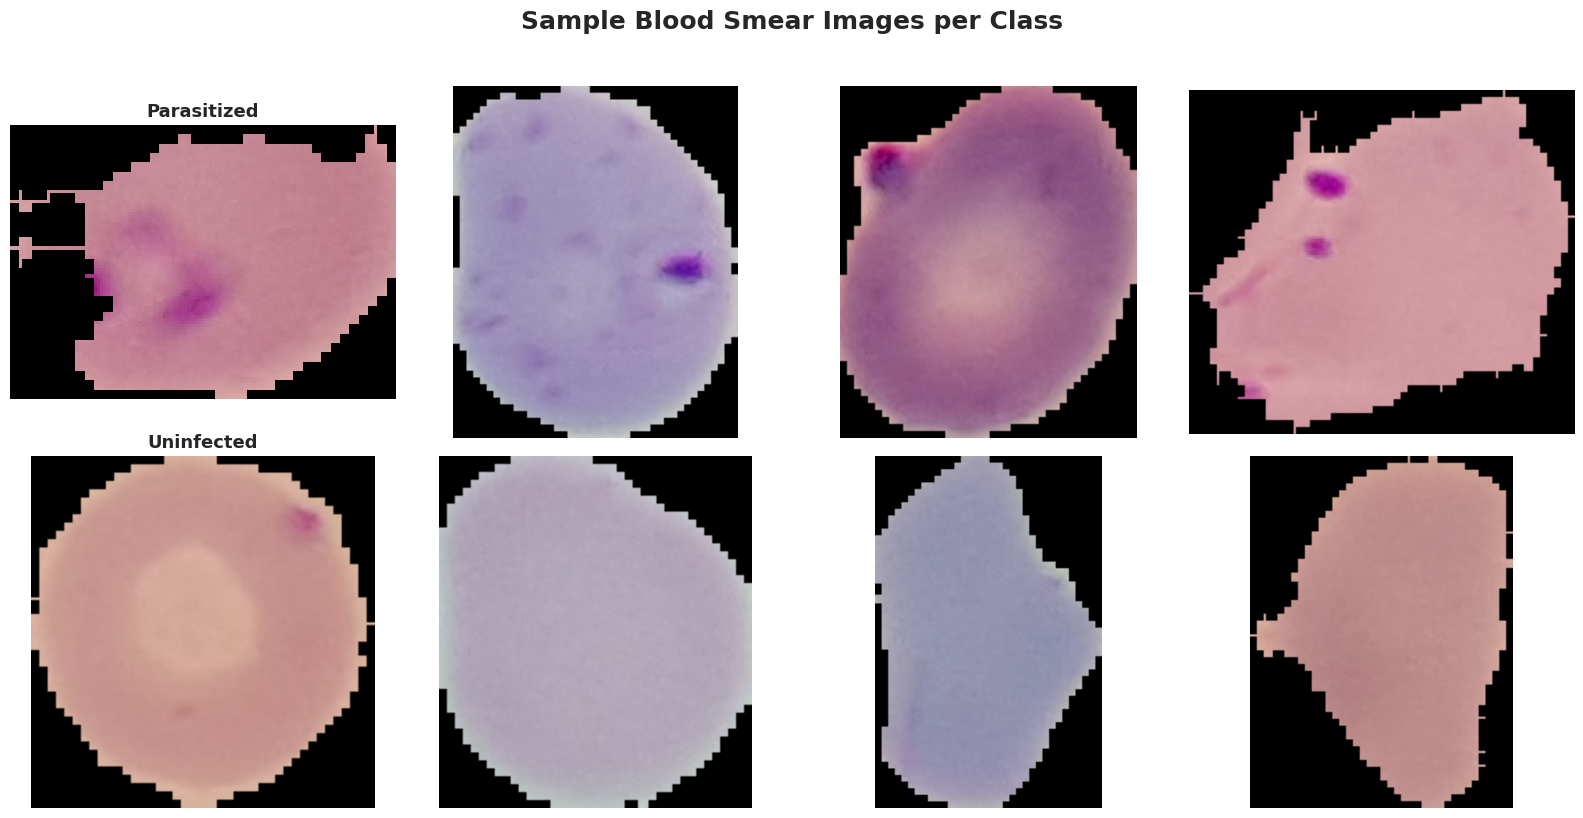

In [10]:
def sample_images_display(folder_path, num_images=4):
    classes = sorted([d for d in os.listdir(folder_path)
                      if os.path.isdir(os.path.join(folder_path, d))])
    fig, axes = plt.subplots(len(classes), num_images,
                             figsize=(4 * num_images, 4 * len(classes)))
    fig.suptitle('Sample Blood Smear Images per Class', fontsize=18,
                 fontweight='bold', y=1.02)

    for i, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected = random.sample(files, min(num_images, len(files)))
        for j, img_name in enumerate(selected):
            img = Image.open(os.path.join(class_path, img_name))
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name.capitalize(), fontsize=13,
                                     fontweight='bold')
    plt.tight_layout()
    plt.show()

sample_images_display('Dataset/train')


## **Exploratory Data Analysis (EDA)**

#### **Class Distribution Across Splits**

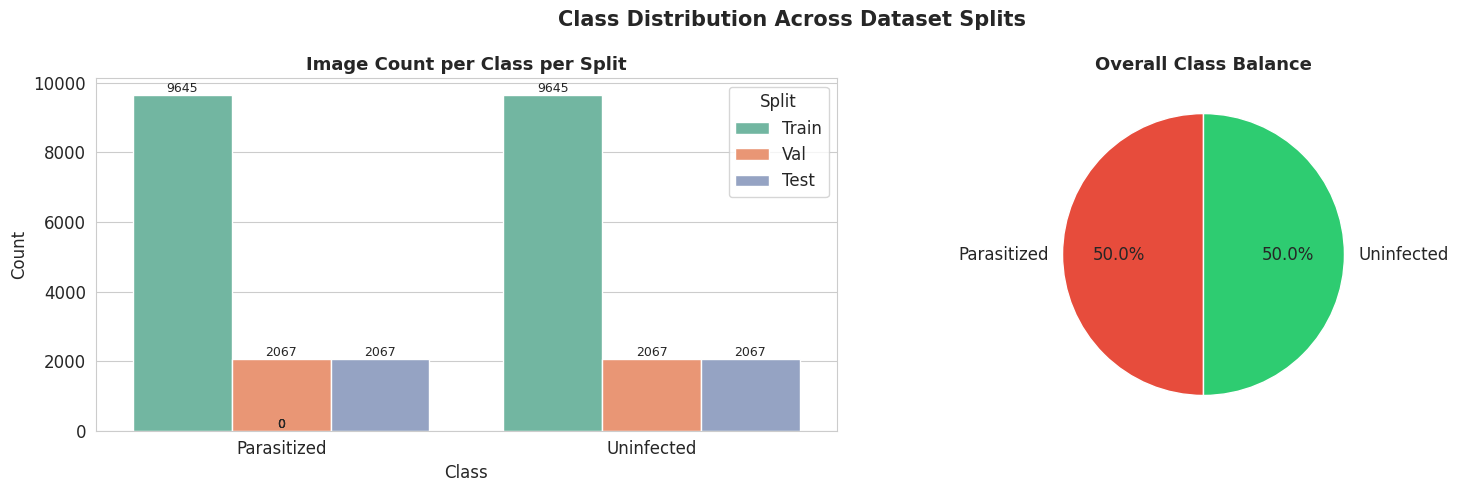

In [11]:
split_data = []
for split in ['train', 'val', 'test']:
    split_path = os.path.join('Dataset', split)
    for c in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, c)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            split_data.append({'Split': split.capitalize(),
                               'Class': c.capitalize(), 'Count': count})

split_df = pd.DataFrame(split_data)
model_colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Class Distribution Across Dataset Splits', fontsize=15, fontweight='bold')

sns.barplot(data=split_df, x='Class', y='Count', hue='Split',
            palette='Set2', ax=axes[0])
axes[0].set_title('Image Count per Class per Split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Split')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

total_per_class = split_df.groupby('Class')['Count'].sum()
axes[1].pie(total_per_class, labels=total_per_class.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Overall Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


#### **Image Dimension Analysis**

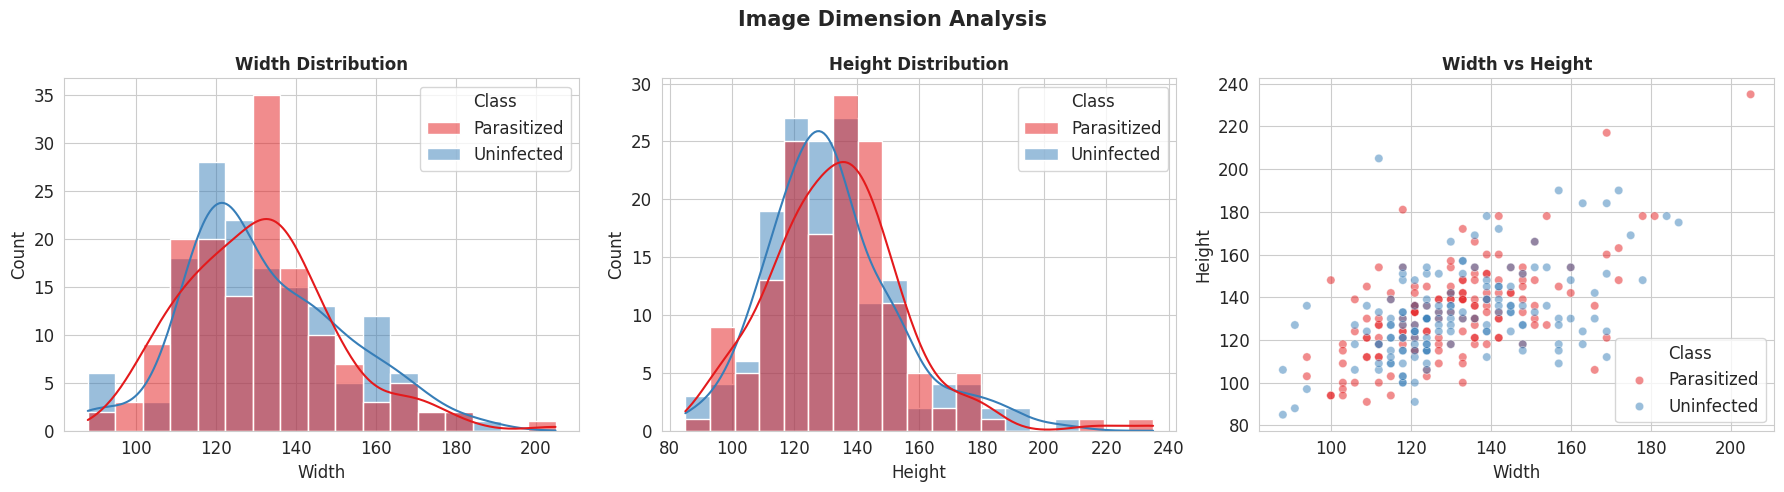

In [12]:
widths, heights, aspect_ratios, img_classes = [], [], [], []
train_path_eda = 'Dataset/train'

for class_name in sorted(os.listdir(train_path_eda)):
    class_path = os.path.join(train_path_eda, class_name)
    if not os.path.isdir(class_path):
        continue
    sample_files = os.listdir(class_path)
    for img_name in random.sample(sample_files, min(150, len(sample_files))):
        try:
            img = Image.open(os.path.join(class_path, img_name))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            img_classes.append(class_name.capitalize())
        except Exception:
            continue

dim_df = pd.DataFrame({'Width': widths, 'Height': heights,
                       'Aspect Ratio': aspect_ratios, 'Class': img_classes})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Image Dimension Analysis', fontsize=15, fontweight='bold')

sns.histplot(data=dim_df, x='Width', hue='Class', kde=True,
             palette='Set1', ax=axes[0])
axes[0].set_title('Width Distribution', fontsize=12, fontweight='bold')

sns.histplot(data=dim_df, x='Height', hue='Class', kde=True,
             palette='Set1', ax=axes[1])
axes[1].set_title('Height Distribution', fontsize=12, fontweight='bold')

sns.scatterplot(data=dim_df, x='Width', y='Height', hue='Class',
                alpha=0.5, palette='Set1', ax=axes[2])
axes[2].set_title('Width vs Height', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


#### **Mean Pixel Intensity per Class**

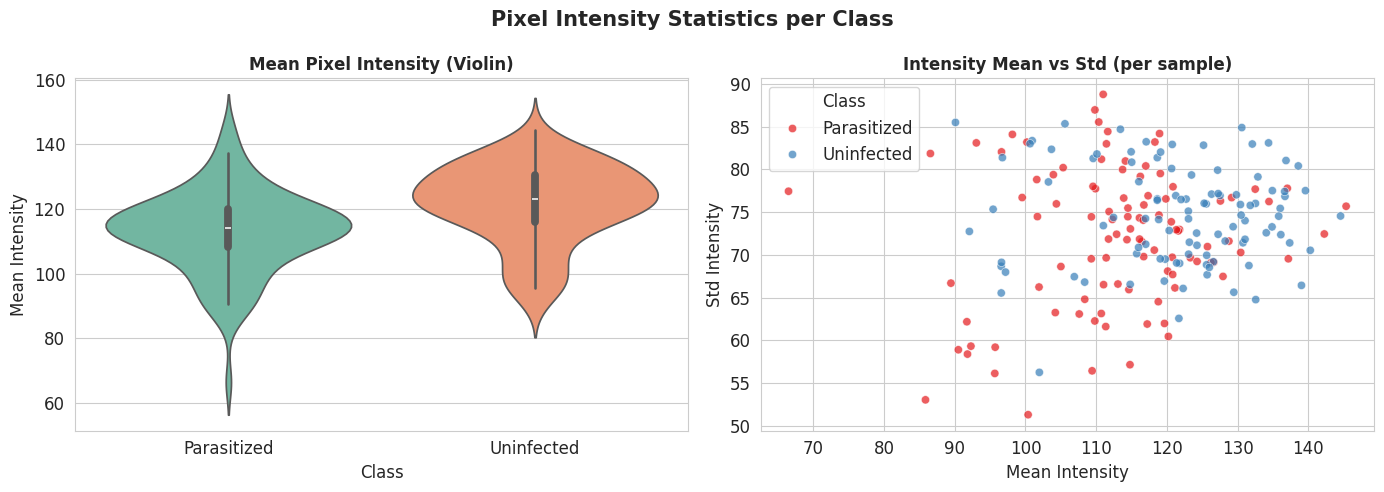

In [13]:
intensity_data = []

for class_name in sorted(os.listdir(train_path_eda)):
    class_path = os.path.join(train_path_eda, class_name)
    if not os.path.isdir(class_path):
        continue
    sample_files = os.listdir(class_path)
    for img_name in random.sample(sample_files, min(100, len(sample_files))):
        try:
            img = Image.open(os.path.join(class_path, img_name)).convert('L')
            arr = np.array(img)
            intensity_data.append({'Class': class_name.capitalize(),
                                   'Mean Intensity': arr.mean(),
                                   'Std Intensity': arr.std()})
        except Exception:
            continue

intensity_df = pd.DataFrame(intensity_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Statistics per Class', fontsize=15, fontweight='bold')

sns.violinplot(data=intensity_df, x='Class', y='Mean Intensity',
               palette='Set2', ax=axes[0], inner='box')
axes[0].set_title('Mean Pixel Intensity (Violin)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Intensity')

sns.scatterplot(data=intensity_df, x='Mean Intensity', y='Std Intensity',
                hue='Class', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Intensity Mean vs Std (per sample)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


#### **RGB Channel Distribution by Class**

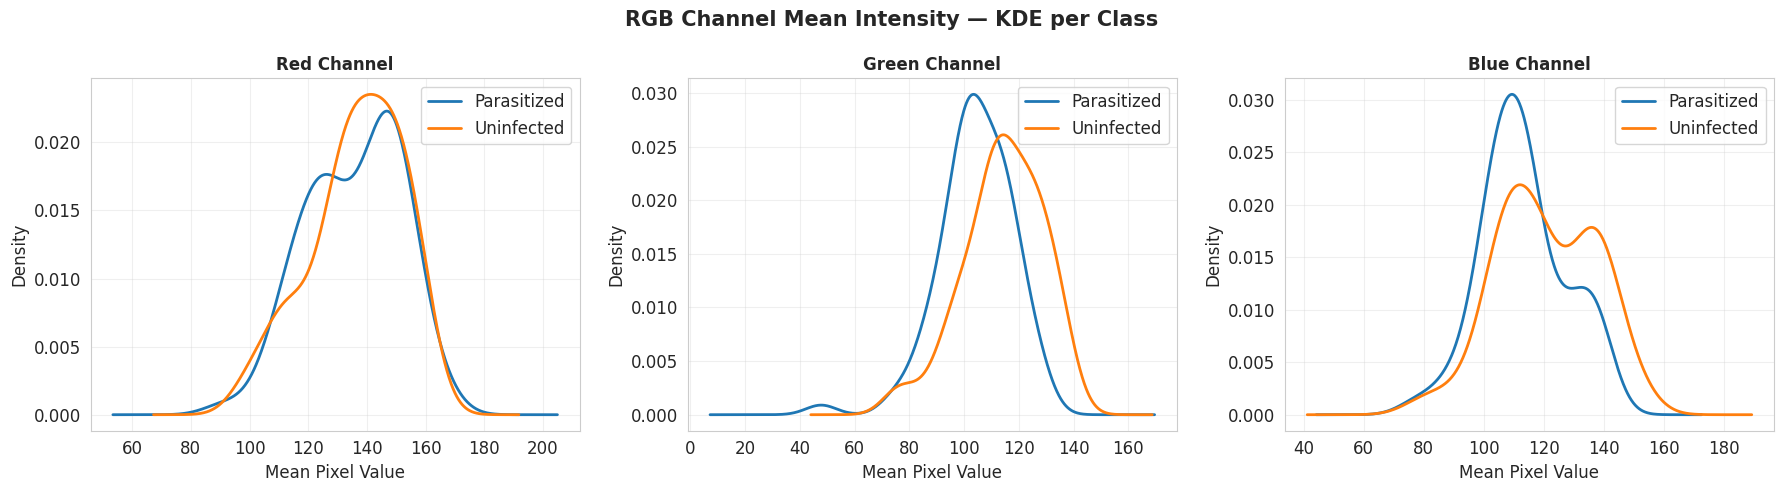

In [14]:
channel_data = []

for class_name in sorted(os.listdir(train_path_eda)):
    class_path = os.path.join(train_path_eda, class_name)
    if not os.path.isdir(class_path):
        continue
    sample_files = os.listdir(class_path)
    for img_name in random.sample(sample_files, min(80, len(sample_files))):
        try:
            img = Image.open(os.path.join(class_path, img_name)).convert('RGB')
            arr = np.array(img)
            channel_data.append({'Class': class_name.capitalize(),
                                 'Red':   arr[:, :, 0].mean(),
                                 'Green': arr[:, :, 1].mean(),
                                 'Blue':  arr[:, :, 2].mean()})
        except Exception:
            continue

channel_df = pd.DataFrame(channel_data)
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']
channel_names = ['Red', 'Green', 'Blue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RGB Channel Mean Intensity — KDE per Class', fontsize=15, fontweight='bold')

for ax, ch, color in zip(axes, channel_names, ch_colors):
    for cls in channel_df['Class'].unique():
        subset = channel_df[channel_df['Class'] == cls][ch]
        subset.plot.kde(ax=ax, label=cls, linewidth=2)
    ax.set_title(f'{ch} Channel', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Pixel Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## **Data Generator Setup**

In [15]:
np.random.seed(42)
tf.random.set_seed(42)

train_path = 'Dataset/train'
val_path   = 'Dataset/val'
test_path  = 'Dataset/test'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True)

print("\nLoading Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

print("\nLoading Test Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

CLASS_NAMES = list(train_generator.class_indices.keys())
print(f"\nClass indices: {train_generator.class_indices}")
print(f"Class names  : {CLASS_NAMES}")


Loading Training Data:
Found 19290 images belonging to 2 classes.

Loading Validation Data:
Found 4134 images belonging to 2 classes.

Loading Test Data:
Found 4134 images belonging to 2 classes.

Class indices: {'parasitized': 0, 'uninfected': 1}
Class names  : ['parasitized', 'uninfected']
